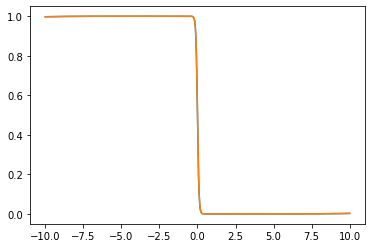

Directory called EM already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called EP already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called Device already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Running TB-Trans in Directory: Device!


 Building ES - H - Self Energies 


 Overlap Included!

Normal plot


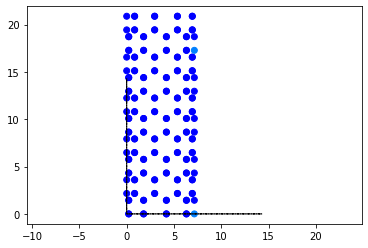

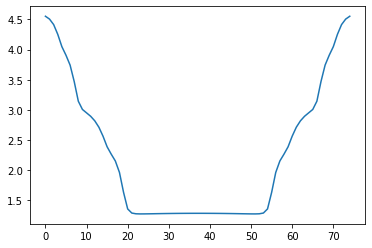

In [1]:
import sisl
from TimedependentTransport.TimedependentTransport import TD_Transport
import numpy as np
import matplotlib.pyplot as plt

a  = 1.44
tz = 5

C = sisl.Atom('C', R= 1.6)
cnt = sisl.geom.nanotube(a,atoms = C, chirality = (9,0))

dev = sisl.Hamiltonian(cnt.tile(tz,2))
em  = sisl.Hamiltonian(cnt.copy())
ep  = sisl.Hamiltonian(cnt.copy().move(dev.cell[2,:] - em.cell[2,:]))
dev.construct([[0.1, a * 1.1],[0.0, -2.7]])
em.construct([[0.1, a * 1.1],[0.0,  -2.7]])
ep.construct([[0.1, a * 1.1],[0.0,  -2.7]])

eta  = 1j  * 1e-1
line = np.linspace(-3, 3, 75) + eta
line = np.vstack((line,line))

D = TD_Transport([em.geom,ep.geom], dev, kT_i = [0.05, 0.05])
D.Make_Contour(line, 12, pole_mode = 'JieHu2011')
plt.show()

D.Electrodes( semi_infs = ['-a3', '+a3'] , kp = [[1,1,50], [1,1,50]])
D.make_device(elec_inds = [[0], [cnt.na*(tz-1)]])
D.run_electrodes(fois_gras_H = [em,ep])
D.run_device(    fois_gras_H = dev    )
D.read_data()
D.Device.Visualise(axes = [0,2])
plt.show()

plt.plot(D.tbtT[D.sampling_idx[0]])


In [13]:
D.reset_all_fits() # Comment in to reset fits!
NL = 5
min_tol  = -0.0*np.ones(NL)
min_tol1 =  min_tol.copy()
min_tol2 =  min_tol.copy()

def run_mini(its):
    D.Fit(fact = 1.0, Fallback_W = 30.0, NumL = NL,
          fit_mode      = 'all',
          force_PSD     = True,
          force_PSD_tol = [min_tol1, min_tol2],
          use_analytical_jac = True,
          min_method = 'SLSQP',
          ebounds = (-5, 5),
          wbounds = (0.01, 0.8),
          gbounds = (None, None),
          tol = -1,
          options = {'disp':True,'maxiter':its, 
                     'gtol':1e-10,
                     'ftol':1e-10,
                     'iprint':1
                     },
          fit_real_part = False,
          specific_bounds = None,#[{(0 ,2) :[(0.1, 0.11), (4,5)]}, {(0 ,5) :[(-0.1, 0.1), (4,5)]}], 
          alpha_PO = 0.01, 
          )


In [14]:
#D.reset_all_fits()

run_mini(500)

Finding Lambda matrices:

--------------------
Optimizing Lorentzian Expansion
--------------------

Accumulated indices:
[0] [0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8] [0, 1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8, 2, 3, 4, 5, 6, 7, 8, 3, 4, 5, 6, 7, 8, 4, 5, 6, 7, 8, 5, 6, 7, 8, 6, 7, 8, 7, 8, 8]

Bounds on centers:

((-5, 5), (-5, 5), (-5, 5), (-5, 5), (-5, 5))

Bounds on linewidth:

((0.01, 0.8), (0.01, 0.8), (0.01, 0.8), (0.01, 0.8), (0.01, 0.8))


/home/aleksander/Desktop/Input_hpc_master/PythonModules/Block_matrices/Block_matrices/Block_matrices.py:1877: OptimizeWarning: Unknown solver options: gtol
  sol = minimize(f, x0, jac = jac, method = min_method,


Optimization terminated successfully    (Exit mode 0)
            Current function value: 3143.5248363172936
            Iterations: 30
            Function evaluations: 75
            Gradient evaluations: 30
Lorentzian fit took 0.4976687431335449 seconds.
Finding Lambda matrices:

--------------------
Optimizing Lorentzian Expansion
--------------------

Accumulated indices:
[0] [0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 7, 7, 8] [0, 1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8, 2, 3, 4, 5, 6, 7, 8, 3, 4, 5, 6, 7, 8, 4, 5, 6, 7, 8, 5, 6, 7, 8, 6, 7, 8, 7, 8, 8]

Bounds on centers:

((-5, 5), (-5, 5), (-5, 5), (-5, 5), (-5, 5))

Bounds on linewidth:

((0.01, 0.8), (0.01, 0.8), (0.01, 0.8), (0.01, 0.8), (0.01, 0.8))
[-5.         -5.         -4.99998004  5.          5.        ] [0.01       0.01       0.50540064 0.01       0.01      ]
Iteration limit reached    (Exit mode 9)
            Current func

(12, 12)


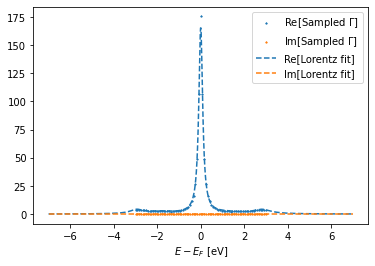

In [15]:
print(D.fitted_lorentzians[1].is_zero.shape)
IK = 0
D.Inspect_Lorentzian_fit(1,11,11,0,0,                          ik = IK, Emin = -7, Emax = 7, center_lines = False)
plt.xlabel(r'$E-E_F$ [eV]')
plt.show()
#D.Inspect_Lorentzian_fit(1,11,11,1,0,                          ik = IK, Emin = -7, Emax = 7)
#plt.show()
#D.Inspect_Lorentzian_fit(0,0,0,1,1,                            ik = IK, Emin = -7, Emax = 7)
#plt.show()
#D.Inspect_Lorentzian_fit(0,0,0,1,0,                            ik = IK, Emin = -7, Emax = 7)


In [8]:

from TimedependentTransport.Pulses import zero_bias, zero_dH
from TimedependentTransport.TimedependentTransport import AdaptiveRK4  as RK4
D.Inspect_transmission_from_SE_fit(eta = 1e-2); 
D.diagonalise()
D.get_propagation_quantities()
D.get_dense_matrices_purenp(1e-8)
D.Check_input_to_ODE(loose_fermi = True)
f     = D.make_f_purenp()
sig   = D.sigma
psi   = D.Psi_vec
omega = D.omegas

no fitted self energies!
Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 17.553348
Minimum of eigenvalues of Lorentzian Gammas: 0.0

 Check the ODECheck.txt file lying in the working directory!


 The values in the file should be small!



In [ ]:
t3, data3 = RK4( f, sig, psi, omega, 1e-5,  -0, 10,  zero_dH, zero_bias, D.Ixi, 0.1, fixed_mode = False, 
                 name = 'Chain')

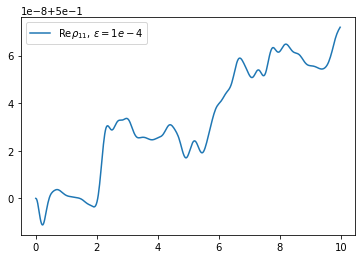

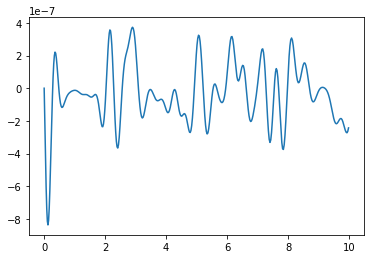

In [29]:
plt.plot(t3, data3['density matrix'][:,0,1,1].real,label = r'Re$\rho_{11}$, $\epsilon = 1e-4$')
plt.legend()
plt.show()
plt.plot(t3,data3['current_left'],label = r'$J_R$')